In [1]:
path = r"C:\Users\ipand\Documents\data_science\example.txt"

In [2]:
open(path).readline()

'{ "a": "Mozilla\\/5.0 (Windows NT 6.1; WOW64) AppleWebKit\\/535.11 (KHTML, like Gecko) Chrome\\/17.0.963.78 Safari\\/535.11", "c": "US", "nk": 1, "tz": "America\\/New_York", "gr": "MA", "g": "A6qOVH", "h": "wfLQtf", "l": "orofrog", "al": "en-US,en;q=0.8", "hh": "1.usa.gov", "r": "http:\\/\\/www.facebook.com\\/l\\/7AQEFzjSi\\/1.usa.gov\\/wfLQtf", "u": "http:\\/\\/www.ncbi.nlm.nih.gov\\/pubmed\\/22415991", "t": 1331923247, "hc": 1331822918, "cy": "Danvers", "ll": [ 42.576698, -70.954903 ] }\n'

### Converting a JSON string to python dict object

In [4]:
import json
records = [json.loads(line) for line in open(path)]

records[0]


{'a': 'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/535.11 (KHTML, like Gecko) Chrome/17.0.963.78 Safari/535.11',
 'c': 'US',
 'nk': 1,
 'tz': 'America/New_York',
 'gr': 'MA',
 'g': 'A6qOVH',
 'h': 'wfLQtf',
 'l': 'orofrog',
 'al': 'en-US,en;q=0.8',
 'hh': '1.usa.gov',
 'r': 'http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/wfLQtf',
 'u': 'http://www.ncbi.nlm.nih.gov/pubmed/22415991',
 't': 1331923247,
 'hc': 1331822918,
 'cy': 'Danvers',
 'll': [42.576698, -70.954903]}

### Counting the timezones 

In [5]:
time_zones = [rec['tz'] for rec in records]

KeyError: 'tz'

In [8]:
# Handling the missing values
#Not all records have a time zone, so we need to filter out the missing values. We can do this using a list comprehension that only includes records with a non-empty 'tz' field.

time_zones = [rec['tz'] for rec in records if 'tz' in rec]

time_zones[:8]

['America/New_York',
 'America/Denver',
 'America/New_York',
 'America/Sao_Paulo',
 'America/New_York',
 'America/New_York',
 'Europe/Warsaw',
 '']

In [10]:
#Getting counts of each time zone

def get_counts(sequence):
    counts ={}
    for x in sequence:
        if x in counts:
            counts[x]+=1
        else:  
            counts[x]=1
    return counts

In [11]:
#Using libraries

from collections import defaultdict
def get_counts2(sequence):
    counts = defaultdict(int)#values will be initialized at 0
    for x in sequence:
        counts[x]+=1
    return counts  # the difference is that we don't need to check if the key exists in the dictionary before incrementing its value. The defaultdict will automatically create a new entry with a default value of 0 if the key doesn't exist yet.    
    

In [13]:
get_counts(time_zones)



{'America/New_York': 1251,
 'America/Denver': 191,
 'America/Sao_Paulo': 33,
 'Europe/Warsaw': 16,
 '': 521,
 'America/Los_Angeles': 382,
 'Asia/Hong_Kong': 10,
 'Europe/Rome': 27,
 'Africa/Ceuta': 2,
 'Europe/Madrid': 35,
 'Asia/Kuala_Lumpur': 3,
 'Asia/Nicosia': 1,
 'Europe/London': 74,
 'Pacific/Honolulu': 36,
 'America/Chicago': 400,
 'Europe/Malta': 2,
 'Europe/Lisbon': 8,
 'Europe/Paris': 14,
 'Europe/Copenhagen': 5,
 'America/Mazatlan': 1,
 'Europe/Dublin': 3,
 'Europe/Brussels': 4,
 'America/Vancouver': 12,
 'Europe/Amsterdam': 22,
 'Europe/Prague': 10,
 'Europe/Stockholm': 14,
 'America/Anchorage': 5,
 'Asia/Bangkok': 6,
 'Europe/Berlin': 28,
 'America/Rainy_River': 25,
 'Europe/Budapest': 5,
 'Asia/Tokyo': 37,
 'Europe/Vienna': 6,
 'America/Phoenix': 20,
 'Asia/Jerusalem': 3,
 'Asia/Karachi': 3,
 'America/Bogota': 3,
 'America/Indianapolis': 20,
 'America/Montreal': 9,
 'Asia/Calcutta': 9,
 'Europe/Skopje': 1,
 'Asia/Beirut': 4,
 'Australia/NSW': 6,
 'Chile/Continental': 6,
 

In [17]:
counts = get_counts2(time_zones)

counts['America/New_York']

1251

In [19]:
#Getting top 10 time zones

def get_top_n(count_dict, n):
    val_key_pairs = [(count , tz) for tz,count in count_dict.items()]
    val_key_pairs.sort()
    return val_key_pairs[-n:]
    
 
    
top_10 =get_top_n(counts, n=10)  
top_10 

[(33, 'America/Sao_Paulo'),
 (35, 'Europe/Madrid'),
 (36, 'Pacific/Honolulu'),
 (37, 'Asia/Tokyo'),
 (74, 'Europe/London'),
 (191, 'America/Denver'),
 (382, 'America/Los_Angeles'),
 (400, 'America/Chicago'),
 (521, ''),
 (1251, 'America/New_York')]

In [20]:
#Using the collections.Counter class

from collections import Counter
counts = Counter(time_zones)
counts.most_common(10)

[('America/New_York', 1251),
 ('', 521),
 ('America/Chicago', 400),
 ('America/Los_Angeles', 382),
 ('America/Denver', 191),
 ('Europe/London', 74),
 ('Asia/Tokyo', 37),
 ('Pacific/Honolulu', 36),
 ('Europe/Madrid', 35),
 ('America/Sao_Paulo', 33)]

## USING PANDAS

In [32]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.5 MB 11.6 MB/s eta 0:00:01
   -------------- ------------------------- 3.4/9.5 MB 11.0 MB/s eta 0:00:01
   ----------------- ---------------------- 4.2/9.5 MB 7.4 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.5 MB 6.5 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.5 MB 5.2 MB/s eta 0:00:01


In [26]:
%pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------- ----------- 1.3/1.8 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 7.9 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.2
    Uninstalling pip-25.2:
      Successfully uninstalled pip-25.2
Note: you may need to restart the kernel to use updated packages.


In [27]:
import pandas as pd
data_frame = pd.DataFrame(records)
data_frame.info()



<class 'pandas.DataFrame'>
RangeIndex: 3560 entries, 0 to 3559
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a            3440 non-null   str    
 1   c            2919 non-null   str    
 2   nk           3440 non-null   float64
 3   tz           3440 non-null   str    
 4   gr           2919 non-null   str    
 5   g            3440 non-null   str    
 6   h            3440 non-null   str    
 7   l            3440 non-null   str    
 8   al           3094 non-null   str    
 9   hh           3440 non-null   str    
 10  r            3440 non-null   str    
 11  u            3440 non-null   str    
 12  t            3440 non-null   float64
 13  hc           3440 non-null   float64
 14  cy           2919 non-null   str    
 15  ll           2919 non-null   object 
 16  _heartbeat_  120 non-null    float64
 17  kw           93 non-null     str    
dtypes: float64(4), object(1), str(13)
memory usage: 500.8+ KB


In [30]:
data_frame['nk'][:18]

0     1.0
1     0.0
2     1.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    1.0
11    0.0
12    1.0
13    NaN
14    1.0
15    1.0
16    1.0
17    0.0
Name: nk, dtype: float64

In [31]:
#You can also use the value_counts() method of a pandas Series to get the counts of each unique value in a column. This method returns a Series containing the counts of unique values, sorted in descending order. 
tz_counts = data_frame['tz'].value_counts()
tz_counts[:-18]

tz
America/New_York                  1251
                                   521
America/Chicago                    400
America/Los_Angeles                382
America/Denver                     191
                                  ... 
America/Monterrey                    1
America/Argentina/Buenos_Aires       1
Asia/Yekaterinburg                   1
Asia/Manila                          1
America/Caracas                      1
Name: count, Length: 79, dtype: int64

<Axes: ylabel='tz'>

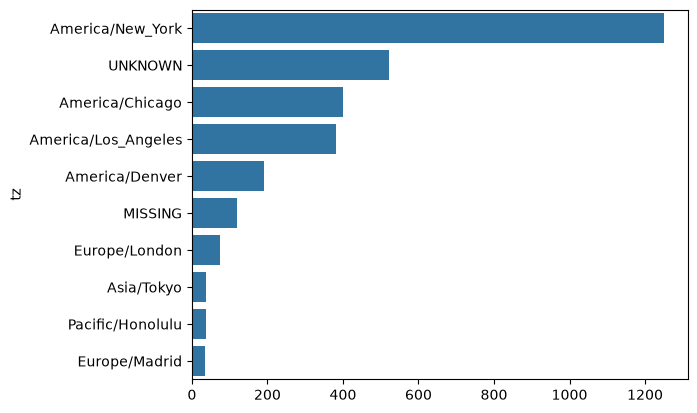

In [33]:
## Cleaning the dataset for plotting, we replace the missing values with 'Missing' and the empty strings with 'Unknown'. We can do this using the fillna() method of a pandas Series to replace the missing values with 'Missing', and the replace() method to replace the empty strings with 'Unknown'.


clean_tz =data_frame['tz'].fillna('MISSING')

clean_tz[clean_tz == ''] = 'UNKNOWN'

tz_counts = clean_tz.value_counts()


import seaborn as sns
subset = tz_counts[:10]

sns.barplot(y= subset.index, x=subset.values)